<a href="https://colab.research.google.com/github/G-Abdusami/week8_lab/blob/main/Practical_Lab_SVM_NumPy_sklearn_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [1]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

NameError: name 'make_moons' is not defined

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

In [ ]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [ ]:
svm_np = LinearSVMFromScratch(C=1.0, learning_rate=0.001, n_iters=250)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [ ]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Explain hinge-loss gradient and max-margin intuition in comments/markdown.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

C=0.1, lr=0.001, Accuracy=0.8533
C=1.0, lr=0.001, Accuracy=0.8267
C=10.0, lr=0.0005, Accuracy=0.8267


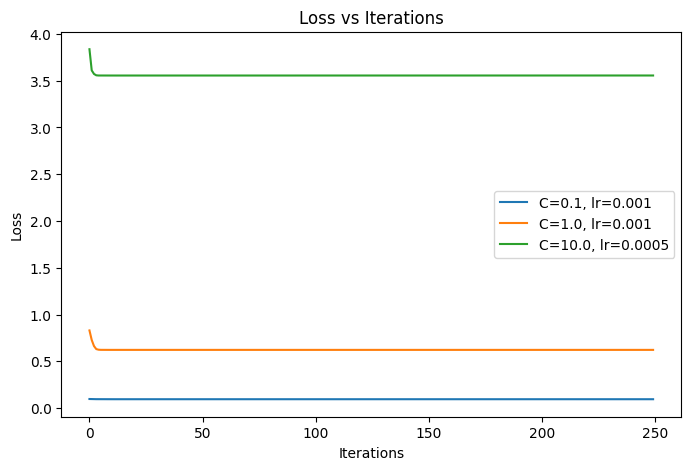

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ================================
# Setup Data
# ================================
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 50% NumPy Task
# ================================

class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i in range(n_samples):
                condition = y_signed[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    grad_w = self.w
                    grad_b = 0
                else:
                    grad_w = self.w - self.C * y_signed[i] * X[i]
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            scores = X @ self.w + self.b
            hinge = np.maximum(0, 1 - y_signed * scores)
            loss = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        preds = np.sign(X @ self.w + self.b)
        return np.where(preds == -1, 0, 1)

# ================================
# Experiments
# ================================

settings = [(0.1, 0.001), (1.0, 0.001), (10.0, 0.0005)]
plt.figure(figsize=(8,5))

for C, lr in settings:
    model = LinearSVMStudent(C=C, learning_rate=lr, n_iters=250)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    print(f"C={C}, lr={lr}, Accuracy={acc:.4f}")
    plt.plot(model.loss_history, label=f"C={C}, lr={lr}")

plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use production-style sklearn workflow with `Pipeline`, scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build `Pipeline(StandardScaler + SVC)` for linear and RBF.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Use param names with pipeline prefix (e.g., `svc__C`, `svc__gamma`).
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Best parameters: {'svc__C': 10, 'svc__gamma': 1}

Model Comparison:
                Model  Accuracy
0    NumPy Linear SVM  0.573333
1  Sklearn Linear SVM  0.840000
2   RBF SVM (untuned)  0.973333
3     RBF SVM (tuned)  0.973333


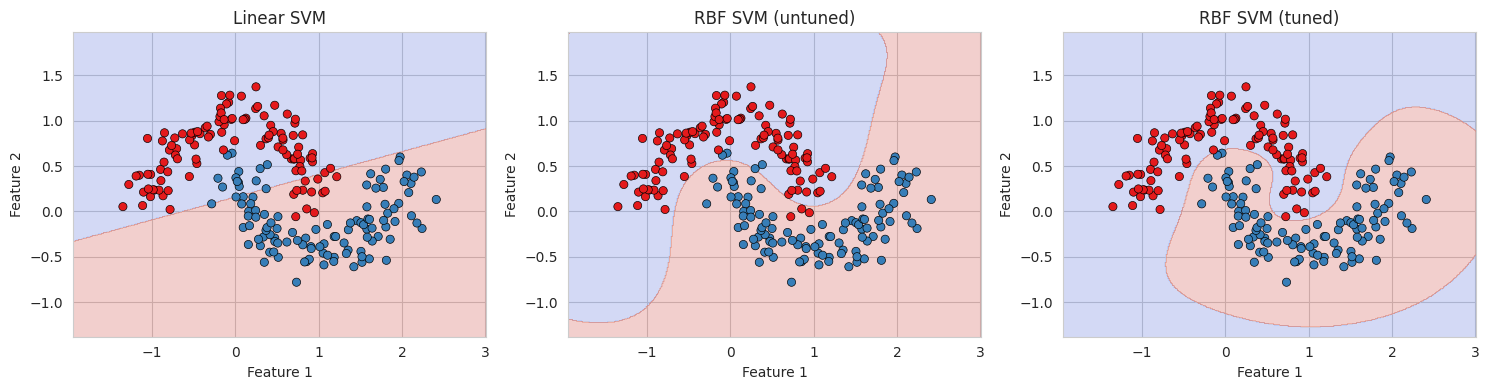

In [13]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# ================================
# 30% sklearn Task
# ================================

# Ensure we are using the moons dataset for this section
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons)

# Fix scaling for the Moons dataset specifically
scaler_moons = StandardScaler()
X_train_scaled_moons = scaler_moons.fit_transform(X_train)
X_test_scaled_moons = scaler_moons.transform(X_test)

# 1) Pipelines
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

# 2) Fit untuned models
pipe_linear.fit(X_train, y_train)
pipe_rbf.fit(X_train, y_train)

# 3) Tune RBF using GridSearchCV
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": [0.01, 0.1, 1]
}

grid = GridSearchCV(pipe_rbf, param_grid, cv=5)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# 4) Compare all 4 models
results = []

if 'model' in globals():
    # Use the specifically scaled moons test data
    pred_np = model.predict(X_test_scaled_moons)
    results.append(["NumPy Linear SVM", accuracy_score(y_test, pred_np)])
else:
    results.append(["NumPy Linear SVM", "Run cell Dip8n6N2m7bb first"])

pred_lin = pipe_linear.predict(X_test)
results.append(["Sklearn Linear SVM", accuracy_score(y_test, pred_lin)])

pred_rbf = pipe_rbf.predict(X_test)
results.append(["RBF SVM (untuned)", accuracy_score(y_test, pred_rbf)])

pred_rbf_tuned = best_rbf.predict(X_test)
results.append(["RBF SVM (tuned)", accuracy_score(y_test, pred_rbf_tuned)])

df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:")
print(df_results)

# 5) Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_decision_boundary(pipe_linear, X_train, y_train, ax=axes[0],
                       title="Linear SVM")

plot_decision_boundary(pipe_rbf, X_train, y_train, ax=axes[1],
                       title="RBF SVM (untuned)")

plot_decision_boundary(best_rbf, X_train, y_train, ax=axes[2],
                       title="RBF SVM (tuned)")

plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report.
- Plot decision boundary using first two PCA components (or discuss feature behavior).
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Use `Pipeline` to avoid leakage.
- Keep one untouched test set for final evaluation.
- If PCA plot looks simplified, note that it is a 2D projection.
- Mention overfitting signs (very high train vs lower test performance).

NumPy SVM -> C=0.1, lr=0.001, Accuracy=0.8400
NumPy SVM -> C=1.0, lr=0.001, Accuracy=0.8267
NumPy SVM -> C=10.0, lr=0.0005, Accuracy=0.8267


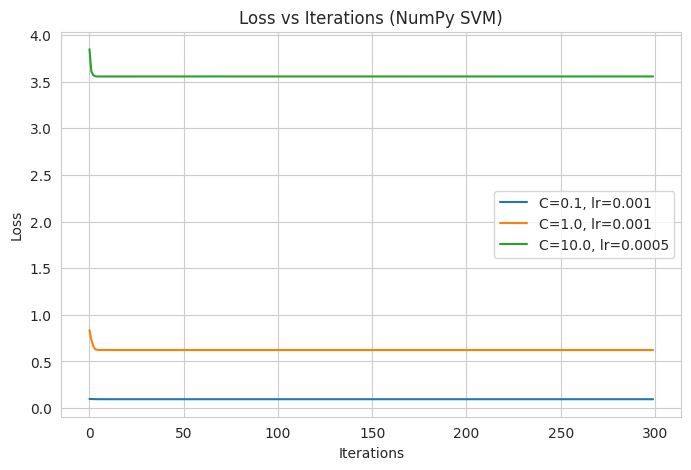

Best RBF params: {'svc__C': 10, 'svc__gamma': 1}

Model Comparison:
Linear SVM: 0.8400
RBF SVM: 0.9733
Tuned RBF: 0.9733

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']

NumPy SVM Accuracy: 0.956140350877193
Sklearn SVM Accuracy: 0.9824561403508771

Classification Report (Sklearn):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  1]
 [ 1 71]]


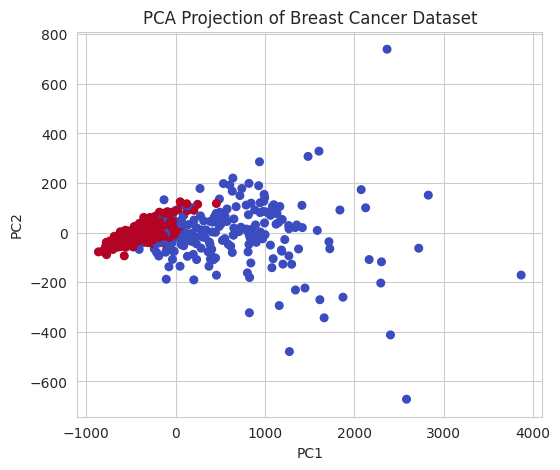

In [5]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)

# ================================
# PART 1 — NUMPY SVM FROM SCRATCH
# ================================

class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state

    def fit(self, X, y):
        y = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    self.w -= self.learning_rate * self.w
                else:
                    self.w -= self.learning_rate * (self.w - self.C * y[i] * X[i])
                    self.b -= self.learning_rate * (-self.C * y[i])

            # compute loss
            loss = 0
            for i in range(n_samples):
                loss += max(0, 1 - y[i] * (np.dot(X[i], self.w) + self.b))
            loss = 0.5 * np.dot(self.w, self.w) + self.C * loss / n_samples

            self.loss_history.append(loss)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        preds = np.sign(X @ self.w + self.b)
        return np.where(preds == -1, 0, 1)


# ================================
# DATASET 1: MAKE_MOONS
# ================================
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# NUMPY EXPERIMENTS (3 SETTINGS)
# ================================
settings = [
    (0.1, 0.001),
    (1.0, 0.001),
    (10.0, 0.0005)
]

plt.figure(figsize=(8,5))

for C, lr in settings:
    model = LinearSVMStudent(C=C, learning_rate=lr)
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)

    print(f"NumPy SVM -> C={C}, lr={lr}, Accuracy={acc:.4f}")
    plt.plot(model.loss_history, label=f"C={C}, lr={lr}")

plt.title("Loss vs Iterations (NumPy SVM)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


# ================================
# PART 2 — SCIKIT-LEARN SVM
# ================================

# Pipelines
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

# Train
pipe_linear.fit(X_train, y_train)
pipe_rbf.fit(X_train, y_train)

# Tune RBF
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": [0.01, 0.1, 1]
}

grid = GridSearchCV(pipe_rbf, param_grid, cv=5)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_

print("Best RBF params:", grid.best_params_)

# Compare models
models = {
    "Linear SVM": pipe_linear,
    "RBF SVM": pipe_rbf,
    "Tuned RBF": best_rbf
}

print("\nModel Comparison:")
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")


# ================================
# PART 3 — REAL DATASET
# ================================
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

print("\nDataset shape:", X_bc.shape)
print("Target names:", bc.target_names)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train NumPy model
model_np = LinearSVMStudent(C=1.0, learning_rate=0.001, n_iters=300)
model_np.fit(X_train_scaled, y_train)
y_pred_np = model_np.predict(X_test_scaled)

# Train sklearn model (best RBF)
model_sklearn = SVC(kernel="rbf", C=1.0, gamma="scale")
model_sklearn.fit(X_train_scaled, y_train)
y_pred_sk = model_sklearn.predict(X_test_scaled)

# Evaluation
print("\nNumPy SVM Accuracy:", accuracy_score(y_test, y_pred_np))
print("Sklearn SVM Accuracy:", accuracy_score(y_test, y_pred_sk))

print("\nClassification Report (Sklearn):")
print(classification_report(y_test, y_pred_sk))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sk))


# ================================
# PCA VISUALIZATION
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bc)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_bc, cmap="coolwarm", s=30)
plt.title("PCA Projection of Breast Cancer Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 5) Additional Notebook Sections

In [7]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


### Reflection Questions
1. Why does RBF outperform linear on moons data
2. How does increasing `C` affect margin and errors?
3. How does `gamma` control complexity in RBF?
4. Why is scaling essential for SVM?
5. What did convergence plots reveal in your NumPy model?